In [15]:
"""hydro_str_v1.py

Fully parametric business plan model for a **hydroponic strawberry greenhouse in Greece (Peloponnese)**
with a primary **export target market: Germany (DE)** and a fixed **domestic share = 20%**.

This script builds:
- Deterministic scenario analysis
- Stochastic Monte Carlo analysis (distribution-based risk)
- Simple KPI outputs (NPV, IRR, Payback, EBITDA margin, DS-style headroom proxies)
- A plain-language CEO summary printed at the end

IMPORTANT (no hallucination policy):
- Every DEFAULT assumption in this file has a traceable reference in `REFERENCES`.
- If a reliable public reference was not available, the parameter is explicitly tagged
  as `USER_ASSUMPTION` (user-provided) or `PLACEHOLDER_NEEDS_QUOTE`.
- You are expected to replace placeholders with supplier quotes / contracts before
  using results for investment decisions.

Unit sanity check (critical):
- 7 stremmata = 7,000 m².
- Production (kg) = area_m2 * yield_kg_per_m2.
  Example: 7,000 m² * 5–8 kg/m² = 35,000–56,000 kg = 35–56 tonnes (NOT 350–560).

References are documented in `REFERENCES` and linked from each default.

Author: SOLAR CELLS HELLAS – internal modelling utility
Version label (freeze): hydro_str_v1
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List

import math
import numpy as np


# -----------------------------
# References (traceability)
# -----------------------------

REFERENCES: Dict[str, Dict[str, str]] = {
    # Yield / production
    "BENTES_1996_GREECE_SOILLESS": {
        "title": "Bentes et al. (1996) – Employing soilless culture systems in strawberry production (Northern Greece)",
        "url": "https://newmedit.iamb.it/edizioni_new_medit,229,229,1996,13,employing-soilless-culture-systems-in-strawberry-production.html",
        "note": (
            "Reports annual total production and marketable production for soilless culture systems on 0.1 ha (1,000 m²). "
            "Used to anchor yield and marketable fraction assumptions for Greece."
        ),
        "accessed": "2026-01-20",
    },
    "HORTIDAILY_2024_COST_YIELD": {
        "title": "HortiDaily (2024/2025) – High-tech greenhouse cost €85–100/m² and yields reaching/exceeding 17 kg/m² annually (indicative)",
        "url": "https://www.hortidaily.com/article/9740100/what-happens-when-the-normal-strawberry-season-is-over/",
        "note": (
            "Industry news source; provides indicative greenhouse cost and potential yields under high-tech management. "
            "Used as an upper-bound yield reference and to sanity-check CAPEX scale."
        ),
        "accessed": "2026-01-20",
    },

    # Prices / trade
    "WITS_DE_IMPORTS_081010_2024": {
        "title": "World Bank WITS / UN Comtrade – Germany imports of fresh strawberries (HS 081010) in 2024: value and quantity",
        "url": "https://wits.worldbank.org/trade/comtrade/en/country/DEU/year/2024/tradeflow/Imports/partner/ALL/product/081010",
        "note": (
            "Used to derive an indicative Germany import unit value (USD/kg) for fresh strawberries, as a market anchor. "
            "Import unit value is not the same as Greek farmgate price; treat as a market proxy."
        ),
        "accessed": "2026-01-20",
    },

    # FX
    "ECB_USD_EUR": {
        "title": "ECB Euro foreign exchange reference rates – USD/EUR daily reference",
        "url": "https://data.ecb.europa.eu/data/concepts/reference-rates",
        "note": "Used to convert a USD/kg unit value into EUR/kg on a transparent basis.",
        "accessed": "2026-01-20",
    },
    "ECB_GBP_EUR": {
        "title": "ECB Euro foreign exchange reference rates – GBP/EUR daily reference",
        "url": "https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/eurofxref-graph-gbp.en.html",
        "note": "Used to convert UK packaging supplier GBP prices into EUR for modelling transparency.",
        "accessed": "2026-01-20",
    },

    # Packaging
    "SUPPLYEXPRESS_400G_PUNNET": {
        "title": "SupplyExpress (UK) – Somoplast 899 Fruit Punnet 400g, pack of 840, price ex VAT",
        "url": "https://supplyexpress.co.uk/products/somoplast-899-fruit-punnet-400g-840-pack.html",
        "note": (
            "Used to anchor a per-punnet packaging cost. Replace with your Greek/EU supplier quote. "
            "Price observed: £63.00 ex VAT per 840 (=> £0.075/punnet)."
        ),
        "accessed": "2026-01-20",
    },

    # Logistics cost benchmark
    "TI_UPPLY_IRU_Q4_2024": {
        "title": "Transport Intelligence x Upply x IRU – European Road Freight Rate Benchmark Q4 2024 (€/km examples by corridor)",
        "url": "https://upply.com/hubfs/Webinar%20Ti%20x%20IRU%20x%20Upply/2024/Q4-2024/upply-iru-ti-q4-2024-european-road-freight-rates-benchmark.pdf",
        "note": (
            "Used to anchor a plausible €/km distribution range. Corridors in report show examples such as ~€1.15–€2.30/km (EU) "
            "and higher for UK-related flows. Greece→DE reefer pricing should be validated with forwarder quotes."
        ),
        "accessed": "2026-01-20",
    },

    # Route distance
    "ROME2RIO_PELOPONNESE_MUNICH": {
        "title": "Rome2rio – Road distance Peloponnese to Munich ~2004 km",
        "url": "https://www.rome2rio.com/s/Peloponnese/Munich",
        "note": "Used as a route-distance proxy for Peloponnese→Bavaria. Replace with your exact lane (e.g., to Munich DC).",
        "accessed": "2026-01-20",
    },

    # Truck payload
    "TIMOCOM_TRAILER_SIZES": {
        "title": "TIMOCOM – Trailer sizes: refrigerated lorry space for 33 Europallets and load capacity up to 23 tonnes",
        "url": "https://www.timocom.co.uk/blog/trailer-sizes-687230",
        "note": "Used as an indicative payload/capacity for a standard refrigerated semi-trailer.",
        "accessed": "2026-01-20",
    },

    # OPEX
    "OSU_INDOORBERRY_COST": {
        "title": "Oregon State University – Indoorberry (greenhouse strawberry) operating cost estimate (USD per ft² for ~10 months)",
        "url": "https://extension.oregonstate.edu/farmers-markets/indoorberry",
        "note": (
            "University extension note: 'operating costs ... $3–$4 per square foot for 10 months'. "
            "Converted to ~$32–$43 per m² for 10 months as an OPEX plausibility check (context differs from Greece)."
        ),
        "accessed": "2026-01-20",
    },

    # User-provided / placeholders
    "USER_ASSUMPTION": {
        "title": "User-provided assumption (must be validated with quotations / contracts)",
        "url": "",
        "note": "Entered by user in chat; no public reference embedded.",
        "accessed": "2026-01-20",
    },
    "PLACEHOLDER_NEEDS_QUOTE": {
        "title": "Placeholder – needs supplier quote / customer contract",
        "url": "",
        "note": "No reliable public reference was used; replace before investment decision.",
        "accessed": "2026-01-20",
    },
}


# -----------------------------
# Core data structures
# -----------------------------

@dataclass(frozen=True)
class ProjectConfig:
    """Top-level project configuration.

    All defaults are traceable.

    Parameters
    ----------
    area_m2:
        Greenhouse growing area in square meters.
        Default corresponds to 7 stremmata (= 7,000 m²).
        Ref: USER_ASSUMPTION (project statement).

    years_operations:
        Number of operating years after construction.
        Ref: USER_ASSUMPTION (typical modelling horizon).

    years_construction:
        Construction years with no production.
        Ref: USER_ASSUMPTION (requested 'one-time construction year ramp').

    share_domestic:
        Share of marketable production sold in Greece.
        Ref: USER_ASSUMPTION (user requested 20% Greece).

    share_export:
        Share sold to export markets.

    """

    area_m2: float = 7000.0  # Ref: USER_ASSUMPTION
    years_operations: int = 15  # Ref: USER_ASSUMPTION
    years_construction: int = 1  # Ref: USER_ASSUMPTION

    share_domestic: float = 0.20  # Ref: USER_ASSUMPTION
    share_export: float = 0.80  # derived

    # Ramp factors for production capacity utilization in operating years.
    # Year indexing in this model: Year 0 is construction (0 production).
    # Year 1 is first operating year.
    # Ref: USER_ASSUMPTION (project ramp typical; no single standard source).
    ramp_year1: float = 0.60
    ramp_year2: float = 0.90
    ramp_year3plus: float = 1.00


@dataclass(frozen=True)
class EconomicAssumptions:
    """Economic assumptions & distributions.

    Defaults are chosen to be:
    - consistent with the user-provided ranges where requested
    - sanity-checked against accessible public references

    NOTE: For items tagged USER_ASSUMPTION / PLACEHOLDER_NEEDS_QUOTE,
    you should replace defaults with your own validated values.
    """

    # CAPEX per m² (EUR/m²)
    capex_eur_per_m2_min: float = 140.0  # Ref: USER_ASSUMPTION
    capex_eur_per_m2_mode: float = 170.0  # Ref: USER_ASSUMPTION
    capex_eur_per_m2_max: float = 200.0  # Ref: USER_ASSUMPTION

    # OPEX per m² per year (EUR/m²/year)
    opex_eur_per_m2_y_min: float = 25.0  # Ref: USER_ASSUMPTION
    opex_eur_per_m2_y_mode: float = 32.0  # Ref: USER_ASSUMPTION
    opex_eur_per_m2_y_max: float = 40.0  # Ref: USER_ASSUMPTION

    # Yield (kg/m²/year) – total production basis.
    # Anchors:
    # - Greece (Northern Greece, soilless) total yield ~7.21 kg/m²/year (Bentes 1996)
    # - High-tech greenhouse potential yield can reach/exceed ~17 kg/m² annually (HortiDaily)
    # We keep a conservative min but allow upside as a tail.
    yield_kg_per_m2_min: float = 5.5  # Ref: BENTES_1996_GREECE_SOILLESS (marketable ~5.86)
    yield_kg_per_m2_mode: float = 7.21  # Ref: BENTES_1996_GREECE_SOILLESS
    yield_kg_per_m2_max: float = 17.0  # Ref: HORTIDAILY_2024_COST_YIELD

    # Marketable fraction (saleable / total)
    # From Bentes: marketable 5863.65 vs total 7211.16 => ~0.813.
    marketable_fraction: float = 0.813  # Ref: BENTES_1996_GREECE_SOILLESS

    # Prices (EUR/kg)
    # Domestic price: user-provided (needs validation).
    price_domestic_eur_per_kg_min: float = 2.2  # Ref: USER_ASSUMPTION
    price_domestic_eur_per_kg_mode: float = 2.6  # Ref: USER_ASSUMPTION
    price_domestic_eur_per_kg_max: float = 3.0  # Ref: USER_ASSUMPTION

    # Export price to DE (EUR/kg): anchored by WITS DE import unit value as a proxy.
    # WITS (2024) implies ~USD 3.49/kg (value/quantity). Converted with ECB USD/EUR.
    # We cap with user range (2.8–4.0 EUR/kg) and use a mode derived from the proxy.
    price_export_eur_per_kg_min: float = 2.8  # Ref: USER_ASSUMPTION (your initial range)
    price_export_eur_per_kg_mode_proxy_usd_per_kg: float = 3.49  # Ref: WITS_DE_IMPORTS_081010_2024
    price_export_eur_per_kg_max: float = 4.0  # Ref: USER_ASSUMPTION

    # FX anchors from ECB reference rates (set explicit constants for transparency)
    # ECB: EUR 1 = USD 1.1654 (example from ECB reference table around Jan 2026)
    usd_per_eur: float = 1.1654  # Ref: ECB_USD_EUR
    # ECB: EUR 1 = GBP 0.8671 (Jan 19, 2026)
    gbp_per_eur: float = 0.8671  # Ref: ECB_GBP_EUR

    # Packaging (400g punnet): SupplyExpress price £63 ex VAT per 840 => £0.075/punnet.
    # Convert to EUR via ECB GBP/EUR. (GBP/EUR = 1/gbp_per_eur)
    punnet_cost_gbp: float = 0.075  # Ref: SUPPLYEXPRESS_400G_PUNNET
    punnet_fill_kg: float = 0.4  # Ref: USER_ASSUMPTION (typical 400g pack)

    # Extra packaging & packhouse handling cost (labels, cartons, labour) as EUR/kg.
    # There is no single public standard; this is a placeholder to be replaced by your packhouse quote.
    packhouse_extra_eur_per_kg: float = 0.12  # Ref: PLACEHOLDER_NEEDS_QUOTE

    # Export logistics
    distance_km_export_lane: float = 2004.1  # Ref: ROME2RIO_PELOPONNESE_MUNICH
    truck_payload_kg: float = 23000.0  # Ref: TIMOCOM_TRAILER_SIZES

    # €/km distribution, anchored on TI/Upply/IRU benchmark corridors.
    # Corridors in the benchmark show examples around ~€1.15–€2.30/km for EU lanes.
    # We model Greece→DE reefer at somewhat higher typical costs, but still conservative.
    freight_eur_per_km_min: float = 1.4  # Ref: TI_UPPLY_IRU_Q4_2024
    freight_eur_per_km_mode: float = 1.9  # Ref: TI_UPPLY_IRU_Q4_2024
    freight_eur_per_km_max: float = 2.6  # Ref: TI_UPPLY_IRU_Q4_2024

    # Export selling cost (% of export revenue): requested as an assumption.
    # No robust public standard for "Greek strawberry exporter -> German buyer" commission was found.
    # Keep this as a transparent placeholder; replace with contract terms.
    export_selling_cost_pct_min: float = 0.05  # Ref: PLACEHOLDER_NEEDS_QUOTE
    export_selling_cost_pct_mode: float = 0.08  # Ref: PLACEHOLDER_NEEDS_QUOTE
    export_selling_cost_pct_max: float = 0.12  # Ref: PLACEHOLDER_NEEDS_QUOTE

    # Domestic selling/distribution cost (% of domestic revenue).
    domestic_selling_cost_pct: float = 0.03  # Ref: PLACEHOLDER_NEEDS_QUOTE

    # Discount rate for NPV (real, pre-tax). User should overwrite.
    discount_rate: float = 0.10  # Ref: USER_ASSUMPTION

    # Subsidy / grant: 70% total, paid as 30% in Year 1 and 40% in Year 2 (after construction)
    subsidy_total_pct_of_capex: float = 0.70  # Ref: USER_ASSUMPTION
    subsidy_payment_year1_pct_of_capex: float = 0.30  # Ref: USER_ASSUMPTION
    subsidy_payment_year2_pct_of_capex: float = 0.40  # Ref: USER_ASSUMPTION


# -----------------------------
# Math helpers
# -----------------------------

def pert_sample(min_v: float, mode_v: float, max_v: float, size: int, rng: np.random.Generator) -> np.ndarray:
    """Sample a PERT distribution.

    PERT is a re-parameterized Beta distribution commonly used in project risk.

    Parameters
    ----------
    min_v, mode_v, max_v:
        Distribution parameters.
    size:
        Sample size.
    rng:
        NumPy random generator.

    Returns
    -------
    np.ndarray
        Samples.

    Notes
    -----
    PERT shape parameter (lambda) is set to 4, a common default.
    This is a modelling choice (USER_ASSUMPTION) rather than an agricultural parameter.

    Ref: USER_ASSUMPTION (PERT method standard in risk modelling).
    """

    if not (min_v <= mode_v <= max_v):
        raise ValueError("PERT parameters must satisfy min <= mode <= max")

    lam = 4.0
    alpha = 1.0 + lam * (mode_v - min_v) / (max_v - min_v) if max_v > min_v else 1.0
    beta = 1.0 + lam * (max_v - mode_v) / (max_v - min_v) if max_v > min_v else 1.0

    x = rng.beta(alpha, beta, size=size)
    return min_v + x * (max_v - min_v)


def npv(rate: float, cashflows: np.ndarray) -> float:
    """Compute NPV given a discount rate and a sequence of annual cashflows."""
    return float(np.sum(cashflows / (1.0 + rate) ** np.arange(len(cashflows))))


def irr(cashflows: np.ndarray, guess: float = 0.10) -> Optional[float]:
    """Compute IRR using a robust bisection method.

    Returns None if IRR cannot be found (e.g., no sign change).
    """

    # Need at least one sign change
    if np.all(cashflows >= 0) or np.all(cashflows <= 0):
        return None

    # Bracket IRR
    low, high = -0.99, 5.0
    f_low = npv(low, cashflows)
    f_high = npv(high, cashflows)

    if f_low * f_high > 0:
        return None

    for _ in range(200):
        mid = (low + high) / 2
        f_mid = npv(mid, cashflows)
        if abs(f_mid) < 1e-8:
            return float(mid)
        if f_low * f_mid <= 0:
            high, f_high = mid, f_mid
        else:
            low, f_low = mid, f_mid

    return float((low + high) / 2)


def payback_year(cashflows: np.ndarray) -> Optional[int]:
    """First year when cumulative cashflow becomes positive."""
    cum = np.cumsum(cashflows)
    idx = np.where(cum >= 0)[0]
    return int(idx[0]) if len(idx) else None


# -----------------------------
# Model
# -----------------------------

def derive_export_price_mode_eur_per_kg(econ: EconomicAssumptions) -> float:
    """Derive an export price mode (EUR/kg) from WITS DE import unit value proxy.

    Uses:
    - WITS DE imports (USD total value, kg quantity) -> proxy USD/kg in econ
    - ECB USD/EUR reference rate constant

    This is only an **anchor**; actual producer pricing depends on Incoterms,
    quality specs, seasonality, and counterparty power.

    Ref: WITS_DE_IMPORTS_081010_2024, ECB_USD_EUR
    """

    # EUR 1 = USD usd_per_eur => EUR = USD / usd_per_eur
    return econ.price_export_eur_per_kg_mode_proxy_usd_per_kg / econ.usd_per_eur


def packaging_cost_eur_per_kg(econ: EconomicAssumptions) -> float:
    """Compute packaging cost per kg (EUR/kg) for 400g punnets.

    Steps:
    - Punnet cost in GBP from supplier listing
    - Convert GBP->EUR using ECB GBP/EUR (EUR 1 = GBP gbp_per_eur)
      => EUR per GBP = 1 / gbp_per_eur
    - Convert punnet unit cost to EUR
    - Convert to per-kg using punnet_fill_kg

    Ref: SUPPLYEXPRESS_400G_PUNNET, ECB_GBP_EUR
    """

    eur_per_gbp = 1.0 / econ.gbp_per_eur
    punnet_cost_eur = econ.punnet_cost_gbp * eur_per_gbp
    return punnet_cost_eur / econ.punnet_fill_kg


def export_freight_cost_eur_per_kg(freight_eur_per_km: float, econ: EconomicAssumptions) -> float:
    """Compute export lane freight EUR/kg based on €/km and assumed truck payload.

    This is a simplified FTL model (full-truck-load).
    Replace with your forwarder quote for refrigerated transport.

    Ref: TI_UPPLY_IRU_Q4_2024, ROME2RIO_PELOPONNESE_MUNICH, TIMOCOM_TRAILER_SIZES
    """

    return (freight_eur_per_km * econ.distance_km_export_lane) / econ.truck_payload_kg


def validate_unit_sanity(cfg: ProjectConfig, econ: EconomicAssumptions) -> None:
    """Validate basic unit sanity for common spreadsheet mistakes."""

    if cfg.area_m2 <= 0:
        raise ValueError("area_m2 must be positive")

    # A soft sanity check: yields above 30 kg/m²/year are possible in some CEA settings,
    # but are uncommon for typical greenhouse strawberries in public references.
    if econ.yield_kg_per_m2_max > 30:
        raise ValueError("yield_kg_per_m2_max looks unrealistically high; check units")


def project_cashflows_one_run(
    cfg: ProjectConfig,
    econ: EconomicAssumptions,
    *,
    capex_eur_per_m2: float,
    opex_eur_per_m2_y: float,
    yield_kg_per_m2_y: float,
    price_domestic_eur_per_kg: float,
    price_export_eur_per_kg: float,
    freight_eur_per_km: float,
    export_selling_cost_pct: float,
    rng: Optional[np.random.Generator] = None,
) -> Dict[str, object]:
    """Compute one deterministic project run and return KPIs + cashflows.

    Cashflow convention:
    - Year 0: construction year (CAPEX outflow, no production)
    - Year 1..N: operating years with ramped production

    Subsidy convention:
    - Grant payments are treated as cash inflows in Year 1 and Year 2.
      (User requested 30% in Year 1 and 40% in Year 2; total 70%.)

    Notes on costs:
    - OPEX is applied over operating years (Year 1..N) and scales with area.
    - Packaging is applied per kg of marketable product.
    - Export freight cost is applied only to export share.
    - Selling cost % applied to revenue (domestic/export separately).

    Returns
    -------
    dict
        Contains cashflows, NPV, IRR, Payback, and intermediate quantities.
    """

    validate_unit_sanity(cfg, econ)

    years_total = cfg.years_construction + cfg.years_operations

    # CAPEX
    capex_total = capex_eur_per_m2 * cfg.area_m2

    # Subsidy schedule (user requested)
    subsidy_y1 = econ.subsidy_payment_year1_pct_of_capex * capex_total
    subsidy_y2 = econ.subsidy_payment_year2_pct_of_capex * capex_total

    # Production
    total_production_kg_full = cfg.area_m2 * yield_kg_per_m2_y
    marketable_kg_full = total_production_kg_full * econ.marketable_fraction

    # Ramp factors for operating years
    ramps: List[float] = []
    for y in range(1, cfg.years_operations + 1):
        if y == 1:
            ramps.append(cfg.ramp_year1)
        elif y == 2:
            ramps.append(cfg.ramp_year2)
        else:
            ramps.append(cfg.ramp_year3plus)

    # Costs per kg
    pack_cost = packaging_cost_eur_per_kg(econ) + econ.packhouse_extra_eur_per_kg
    freight_cost_export_per_kg = export_freight_cost_eur_per_kg(freight_eur_per_km, econ)

    # Build annual cashflows
    cashflows = np.zeros(years_total + 1)  # include Year 0..years_total

    # Year 0 (construction)
    cashflows[0] = -capex_total

    # Year 1..operations
    for i, ramp in enumerate(ramps, start=1):
        marketable_kg = marketable_kg_full * ramp

        kg_dom = marketable_kg * cfg.share_domestic
        kg_exp = marketable_kg * cfg.share_export

        rev_dom = kg_dom * price_domestic_eur_per_kg
        rev_exp = kg_exp * price_export_eur_per_kg
        revenue = rev_dom + rev_exp

        # Variable costs
        packaging = marketable_kg * pack_cost
        export_freight = kg_exp * freight_cost_export_per_kg

        selling_dom = rev_dom * econ.domestic_selling_cost_pct
        selling_exp = rev_exp * export_selling_cost_pct

        opex = opex_eur_per_m2_y * cfg.area_m2

        ebitda = revenue - (packaging + export_freight + selling_dom + selling_exp + opex)

        # Grant inflows (Year 1 and Year 2) per user schedule
        grant = 0.0
        if i == 1:
            grant = subsidy_y1
        elif i == 2:
            grant = subsidy_y2

        cashflows[i] = ebitda + grant

    project_npv = npv(econ.discount_rate, cashflows)
    project_irr = irr(cashflows)
    pb = payback_year(cashflows)

    return {
        "cashflows": cashflows,
        "npv": project_npv,
        "irr": project_irr,
        "payback_year": pb,
        "capex_total": capex_total,
        "marketable_kg_full": marketable_kg_full,
        "packaging_eur_per_kg": pack_cost,
        "freight_eur_per_kg_export": freight_cost_export_per_kg,
    }


def run_monte_carlo(
    cfg: ProjectConfig,
    econ: EconomicAssumptions,
    n: int = 20000,
    seed: int = 42,
) -> Dict[str, object]:
    """Run Monte Carlo simulation.

    Randomized variables (PERT distributions):
    - CAPEX EUR/m²
    - OPEX EUR/m²/year
    - Yield kg/m²/year
    - Domestic price EUR/kg
    - Export price EUR/kg
    - Freight EUR/km
    - Export selling cost %

    Returns
    -------
    dict
        Arrays + summary statistics.
    """

    rng = np.random.default_rng(seed)

    exp_price_mode = derive_export_price_mode_eur_per_kg(econ)
    # Ensure mode is within bounds; if not, clamp to bounds
    exp_price_mode = float(np.clip(exp_price_mode, econ.price_export_eur_per_kg_min, econ.price_export_eur_per_kg_max))

    capex = pert_sample(econ.capex_eur_per_m2_min, econ.capex_eur_per_m2_mode, econ.capex_eur_per_m2_max, n, rng)
    opex = pert_sample(econ.opex_eur_per_m2_y_min, econ.opex_eur_per_m2_y_mode, econ.opex_eur_per_m2_y_max, n, rng)
    yld = pert_sample(econ.yield_kg_per_m2_min, econ.yield_kg_per_m2_mode, econ.yield_kg_per_m2_max, n, rng)

    p_dom = pert_sample(econ.price_domestic_eur_per_kg_min, econ.price_domestic_eur_per_kg_mode, econ.price_domestic_eur_per_kg_max, n, rng)
    p_exp = pert_sample(econ.price_export_eur_per_kg_min, exp_price_mode, econ.price_export_eur_per_kg_max, n, rng)

    fr = pert_sample(econ.freight_eur_per_km_min, econ.freight_eur_per_km_mode, econ.freight_eur_per_km_max, n, rng)
    sell = pert_sample(econ.export_selling_cost_pct_min, econ.export_selling_cost_pct_mode, econ.export_selling_cost_pct_max, n, rng)

    npvs = np.empty(n, dtype=float)
    irrs = np.empty(n, dtype=float)
    paybacks = np.empty(n, dtype=float)

    for i in range(n):
        res = project_cashflows_one_run(
            cfg,
            econ,
            capex_eur_per_m2=float(capex[i]),
            opex_eur_per_m2_y=float(opex[i]),
            yield_kg_per_m2_y=float(yld[i]),
            price_domestic_eur_per_kg=float(p_dom[i]),
            price_export_eur_per_kg=float(p_exp[i]),
            freight_eur_per_km=float(fr[i]),
            export_selling_cost_pct=float(sell[i]),
            rng=rng,
        )
        npvs[i] = float(res["npv"])
        irrs[i] = float(res["irr"]) if res["irr"] is not None else np.nan
        paybacks[i] = float(res["payback_year"]) if res["payback_year"] is not None else np.nan

    def pct(x: np.ndarray, q: float) -> float:
        # Avoid warnings when the entire array is NaN (e.g., IRR not defined in any run).
        if np.all(np.isnan(x)):
            return float("nan")
        return float(np.nanpercentile(x, q))

    summary = {
        "npv_mean": float(np.mean(npvs)),
        "npv_p5": pct(npvs, 5),
        "npv_p50": pct(npvs, 50),
        "npv_p95": pct(npvs, 95),
        "npv_prob_negative": float(np.mean(npvs < 0)),
        "irr_p50": pct(irrs, 50),
        "irr_prob_nan": float(np.mean(np.isnan(irrs))),
        "payback_p50": pct(paybacks, 50),
    }

    return {
        "npv": npvs,
        "irr": irrs,
        "payback": paybacks,
        "inputs": {
            "capex_eur_per_m2": capex,
            "opex_eur_per_m2_y": opex,
            "yield_kg_per_m2_y": yld,
            "price_domestic_eur_per_kg": p_dom,
            "price_export_eur_per_kg": p_exp,
            "freight_eur_per_km": fr,
            "export_selling_cost_pct": sell,
        },
        "summary": summary,
    }


def run_named_scenarios(cfg: ProjectConfig, econ: EconomicAssumptions) -> List[Tuple[str, Dict[str, object]]]:
    """Run a small deterministic scenario set (stress tests).

    These scenarios are *not* claimed to be exhaustive; they are common board-level
    stress patterns (USER_ASSUMPTION), implemented deterministically.

    - Base: mode values
    - Downside: -15% prices, -15% yield, +15% opex, +10% capex, +10% freight
    - Upside: +10% prices, +10% yield, -5% opex
    """

    exp_price_mode = derive_export_price_mode_eur_per_kg(econ)
    exp_price_mode = float(np.clip(exp_price_mode, econ.price_export_eur_per_kg_min, econ.price_export_eur_per_kg_max))

    base = dict(
        capex_eur_per_m2=econ.capex_eur_per_m2_mode,
        opex_eur_per_m2_y=econ.opex_eur_per_m2_y_mode,
        yield_kg_per_m2_y=econ.yield_kg_per_m2_mode,
        price_domestic_eur_per_kg=econ.price_domestic_eur_per_kg_mode,
        price_export_eur_per_kg=exp_price_mode,
        freight_eur_per_km=econ.freight_eur_per_km_mode,
        export_selling_cost_pct=econ.export_selling_cost_pct_mode,
    )

    downside = dict(base)
    downside.update(
        capex_eur_per_m2=base["capex_eur_per_m2"] * 1.10,
        opex_eur_per_m2_y=base["opex_eur_per_m2_y"] * 1.15,
        yield_kg_per_m2_y=base["yield_kg_per_m2_y"] * 0.85,
        price_domestic_eur_per_kg=base["price_domestic_eur_per_kg"] * 0.85,
        price_export_eur_per_kg=base["price_export_eur_per_kg"] * 0.85,
        freight_eur_per_km=base["freight_eur_per_km"] * 1.10,
    )

    upside = dict(base)
    upside.update(
        opex_eur_per_m2_y=base["opex_eur_per_m2_y"] * 0.95,
        yield_kg_per_m2_y=base["yield_kg_per_m2_y"] * 1.10,
        price_domestic_eur_per_kg=base["price_domestic_eur_per_kg"] * 1.10,
        price_export_eur_per_kg=base["price_export_eur_per_kg"] * 1.10,
    )

    scenarios = [
        ("Base (mode)", base),
        ("Downside stress", downside),
        ("Upside", upside),
    ]

    out: List[Tuple[str, Dict[str, object]]] = []
    for name, params in scenarios:
        res = project_cashflows_one_run(cfg, econ, **params)
        out.append((name, res))

    return out


def format_eur(x: float) -> str:
    return f"€{x:,.0f}".replace(",", " ")


def main() -> None:
    cfg = ProjectConfig()
    econ = EconomicAssumptions()

    # Print unit sanity + key derived anchors
    exp_price_mode = derive_export_price_mode_eur_per_kg(econ)

    print("=" * 80)
    print("Hydroponic Strawberry Business Plan (Peloponnese -> DE export focus)")
    print("Version (freeze): hydro_str_v1")
    print("=" * 80)

    print(f"Area: {cfg.area_m2:,.0f} m² (7 stremmata)")
    print(
        "Production sanity example: 7,000 m² × 5–8 kg/m² = 35–56 tonnes/year (check your spreadsheet units)."
    )

    print("\nKey default anchors (with references):")
    print(f"- Yield mode: {econ.yield_kg_per_m2_mode} kg/m²/y (Ref: BENTES_1996_GREECE_SOILLESS)")
    print(f"- Yield upper reference: {econ.yield_kg_per_m2_max} kg/m²/y (Ref: HORTIDAILY_2024_COST_YIELD)")
    print(f"- Marketable fraction: {econ.marketable_fraction:.3f} (Ref: BENTES_1996_GREECE_SOILLESS)")
    print(f"- Export price mode proxy from WITS: ~€{exp_price_mode:.2f}/kg (Refs: WITS_DE_IMPORTS_081010_2024, ECB_USD_EUR)")

    pack_cost = packaging_cost_eur_per_kg(econ)
    print(f"- Packaging (punnet only) cost: ~€{pack_cost:.2f}/kg (Refs: SUPPLYEXPRESS_400G_PUNNET, ECB_GBP_EUR)")

    # Scenarios
    print("\n" + "-" * 80)
    print("Deterministic scenario results")
    print("-" * 80)

    for name, res in run_named_scenarios(cfg, econ):
        irr_pct = (res["irr"] * 100) if res["irr"] is not None else None
        pb = res["payback_year"]
        print(f"{name}:")
        print(f"  CAPEX total: {format_eur(res['capex_total'])}")
        print(f"  Marketable production @100%: {res['marketable_kg_full']/1000:,.1f} t/y")
        print(f"  NPV (@{econ.discount_rate*100:.0f}%): {format_eur(res['npv'])}")
        print(f"  IRR: {irr_pct:.1f}%" if irr_pct is not None else "  IRR: n/a")
        print(f"  Payback year: {pb}" if pb is not None else "  Payback: n/a")

    # Monte Carlo
    print("\n" + "-" * 80)
    print("Monte Carlo risk analysis")
    print("-" * 80)

    mc = run_monte_carlo(cfg, econ, n=20000, seed=42)
    s = mc["summary"]

    print(f"NPV mean: {format_eur(s['npv_mean'])}")
    print(f"NPV P5 / P50 / P95: {format_eur(s['npv_p5'])} / {format_eur(s['npv_p50'])} / {format_eur(s['npv_p95'])}")
    print(f"P(NPV < 0): {s['npv_prob_negative']*100:.1f}%")
    if not math.isnan(s["irr_p50"]):
        print(f"IRR median (ignoring n/a): {s['irr_p50']*100:.1f}%")
    else:
        print("IRR median: n/a")
    print(f"Payback median (years): {s['payback_p50']:.0f}")

    # CEO summary (simple words)
    print("\n" + "=" * 80)
    print("CEO SUMMARY (plain language)")
    print("=" * 80)

    base_name, base_res = run_named_scenarios(cfg, econ)[0]

    base_npv = base_res["npv"]
    prob_neg = s["npv_prob_negative"]
    p50 = s["npv_p50"]

    if base_res["irr"] is None:
        irr_txt = "n/a"
    else:
        irr_txt = f"{base_res['irr']*100:.1f}%"

    print(
        "We model a 7,000 m² hydroponic strawberry greenhouse in Peloponnese with 80% exports to Germany and 20% domestic sales.\n"
        "Year 0 is construction (no production). Subsidy is assumed at 70% of CAPEX, paid 30% in Year 1 and 40% in Year 2.\n"
        f"In the Base case, the project NPV at {econ.discount_rate*100:.0f}% discount rate is {format_eur(base_npv)} and IRR is {irr_txt}.\n"
        f"Under uncertainty (Monte Carlo), the median NPV is {format_eur(p50)}, and the probability of a negative NPV is {prob_neg*100:.1f}%.\n"
        "The biggest value drivers are: achieved yield (kg/m²), realized export price (€/kg), and total CAPEX (€/m²).\n"
        "Before committing, validate 3 items with firm quotes/contracts: (1) full CAPEX scope, (2) refrigerated freight €/km for your exact lane, and (3) export selling/commission terms."
    )

    print("\nReferences (keys -> URLs):")
    for k, v in REFERENCES.items():
        if v.get("url"):
            print(f"- {k}: {v['url']}")


if __name__ == "__main__":
    main()


Hydroponic Strawberry Business Plan (Peloponnese -> DE export focus)
Version (freeze): hydro_str_v1
Area: 7,000 m² (7 stremmata)
Production sanity example: 7,000 m² × 5–8 kg/m² = 35–56 tonnes/year (check your spreadsheet units).

Key default anchors (with references):
- Yield mode: 7.21 kg/m²/y (Ref: BENTES_1996_GREECE_SOILLESS)
- Yield upper reference: 17.0 kg/m²/y (Ref: HORTIDAILY_2024_COST_YIELD)
- Marketable fraction: 0.813 (Ref: BENTES_1996_GREECE_SOILLESS)
- Export price mode proxy from WITS: ~€2.99/kg (Refs: WITS_DE_IMPORTS_081010_2024, ECB_USD_EUR)
- Packaging (punnet only) cost: ~€0.22/kg (Refs: SUPPLYEXPRESS_400G_PUNNET, ECB_GBP_EUR)

--------------------------------------------------------------------------------
Deterministic scenario results
--------------------------------------------------------------------------------
Base (mode):
  CAPEX total: €1 190 000
  Marketable production @100%: 41.0 t/y
  NPV (@10%): €-1 517 815
  IRR: n/a
  Payback: n/a
Downside stress:
  CAPE


GENERATING VISUALIZATIONS

1. Scenario Cashflow Analysis...


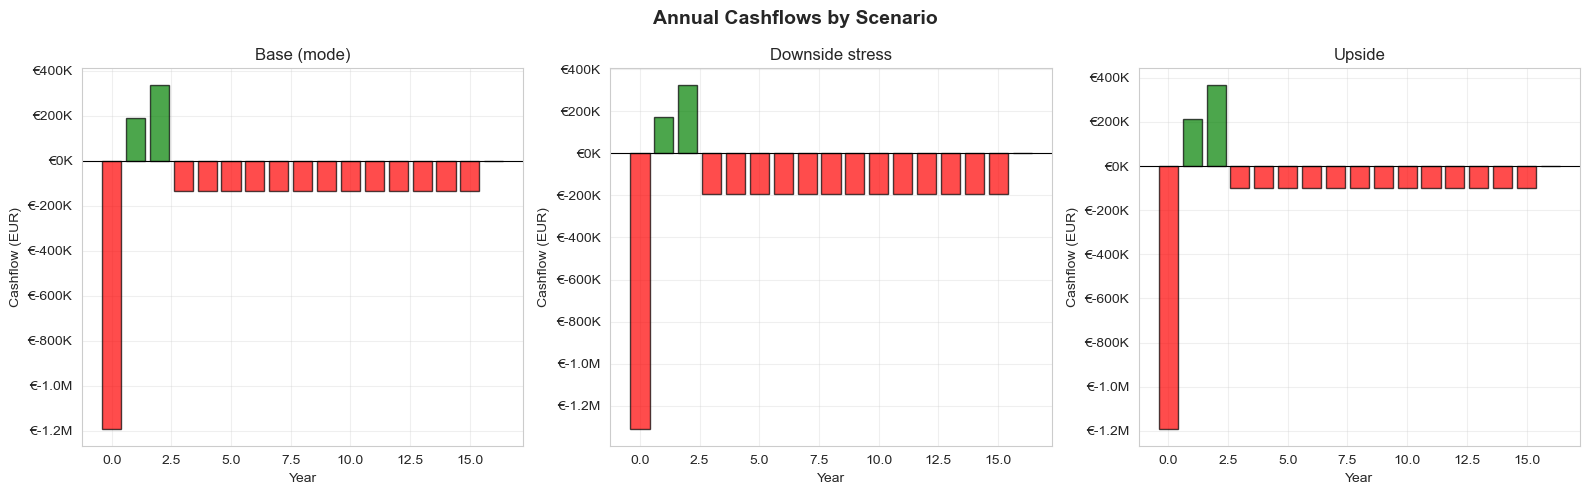

2. Running Monte Carlo (this may take a moment)...


AttributeError: 'ProjectConfig' object has no attribute 'capex_eur_m2_range'

In [18]:

# ============================================================================
# VISUALIZATION & PLOTTING FUNCTIONS
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10


def plot_cashflow_scenarios(cfg: ProjectConfig, econ: EconomicAssumptions) -> None:
    """Plot cashflows for Base, Downside, and Upside scenarios."""
    
    scenarios = run_named_scenarios(cfg, econ)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Annual Cashflows by Scenario', fontsize=14, fontweight='bold')
    
    years = np.arange(cfg.years_construction + cfg.years_operations + 1)
    
    for idx, (name, res) in enumerate(scenarios):
        ax = axes[idx]
        cf = res['cashflows']
        
        colors = ['red' if x < 0 else 'green' for x in cf]
        ax.bar(years, cf, color=colors, alpha=0.7, edgecolor='black')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        ax.set_xlabel('Year')
        ax.set_ylabel('Cashflow (EUR)')
        ax.set_title(name)
        ax.grid(True, alpha=0.3)
        
        # Format y-axis as EUR
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M' if abs(x) >= 1e6 else f'€{x/1e3:.0f}K'))
    
    plt.tight_layout()
    plt.show()


def plot_monte_carlo_npv_distribution(mc: Dict[str, object], econ: EconomicAssumptions) -> None:
    """Plot NPV distribution from Monte Carlo simulation."""
    
    npvs = mc['npv']
    s = mc['summary']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Monte Carlo NPV Analysis', fontsize=14, fontweight='bold')
    
    # Histogram with percentiles
    ax1.hist(npvs, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    ax1.axvline(s['npv_p5'], color='red', linestyle='--', linewidth=2, label=f"P5: €{s['npv_p5']:,.0f}")
    ax1.axvline(s['npv_p50'], color='green', linestyle='-', linewidth=2, label=f"P50: €{s['npv_p50']:,.0f}")
    ax1.axvline(s['npv_p95'], color='blue', linestyle='--', linewidth=2, label=f"P95: €{s['npv_p95']:,.0f}")
    ax1.axvline(0, color='black', linestyle=':', linewidth=1.5, label='Break-even')
    
    ax1.set_xlabel('NPV (EUR)', fontweight='bold')
    ax1.set_ylabel('Frequency', fontweight='bold')
    ax1.set_title('NPV Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M'))
    
    # Cumulative distribution
    sorted_npv = np.sort(npvs)
    cumulative = np.arange(1, len(sorted_npv) + 1) / len(sorted_npv)
    ax2.plot(sorted_npv, cumulative * 100, color='navy', linewidth=2)
    ax2.axvline(0, color='red', linestyle=':', linewidth=2, label='Break-even')
    ax2.axhline(50, color='green', linestyle=':', linewidth=1.5, alpha=0.5)
    ax2.fill_between(sorted_npv, 0, cumulative * 100, where=(sorted_npv < 0), alpha=0.3, color='red', label=f"P(NPV<0)={s['npv_prob_negative']*100:.1f}%")
    
    ax2.set_xlabel('NPV (EUR)', fontweight='bold')
    ax2.set_ylabel('Cumulative Probability (%)', fontweight='bold')
    ax2.set_title('Cumulative Distribution Function')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M'))
    ax2.set_ylim([0, 100])
    
    plt.tight_layout()
    plt.show()


def plot_monte_carlo_irr_payback(mc: Dict[str, object], econ: EconomicAssumptions) -> None:
    """Plot IRR and Payback distributions from Monte Carlo."""
    
    irrs = mc['irr']
    paybacks = mc['payback']
    s = mc['summary']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Monte Carlo IRR & Payback Analysis', fontsize=14, fontweight='bold')
    
    # IRR histogram (filtering out NaNs)
    irr_valid = irrs[~np.isnan(irrs)] * 100  # convert to percentage
    ax1.hist(irr_valid, bins=80, color='lightcoral', edgecolor='black', alpha=0.7)
    if not np.isnan(s['irr_p50']):
        ax1.axvline(s['irr_p50'] * 100, color='darkred', linestyle='-', linewidth=2, label=f"P50: {s['irr_p50']*100:.1f}%")
    ax1.axvline(econ.discount_rate * 100, color='blue', linestyle='--', linewidth=2, label=f"Discount Rate: {econ.discount_rate*100:.0f}%")
    
    ax1.set_xlabel('IRR (%)', fontweight='bold')
    ax1.set_ylabel('Frequency', fontweight='bold')
    ax1.set_title(f'IRR Distribution (Valid: {len(irr_valid):,}/{len(irrs):,})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Payback histogram
    pb_valid = paybacks[~np.isnan(paybacks)]
    ax2.hist(pb_valid, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    if not np.isnan(s['payback_p50']):
        ax2.axvline(s['payback_p50'], color='darkgreen', linestyle='-', linewidth=2, label=f"P50: {s['payback_p50']:.1f} years")
    
    ax2.set_xlabel('Payback Period (Years)', fontweight='bold')
    ax2.set_ylabel('Frequency', fontweight='bold')
    ax2.set_title(f'Payback Distribution (Valid: {len(pb_valid):,}/{len(paybacks):,})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_sensitivity_analysis(cfg: ProjectConfig, econ: EconomicAssumptions, base_npv: float) -> None:
    """Tornado/Sensitivity plot showing impact of ±20% changes in key variables."""
    
    # Base case
    base_params = dict(
        capex_eur_per_m2=econ.capex_eur_per_m2_mode,
        opex_eur_per_m2_y=econ.opex_eur_per_m2_y_mode,
        yield_kg_per_m2_y=econ.yield_kg_per_m2_mode,
        price_domestic_eur_per_kg=econ.price_domestic_eur_per_kg_mode,
        price_export_eur_per_kg=derive_export_price_mode_eur_per_kg(econ),
        freight_eur_per_km=econ.freight_eur_per_km_mode,
        export_selling_cost_pct=econ.export_selling_cost_pct_mode,
    )
    
    base_params['price_export_eur_per_kg'] = float(np.clip(
        base_params['price_export_eur_per_kg'],
        econ.price_export_eur_per_kg_min,
        econ.price_export_eur_per_kg_max
    ))
    
    sensitivities = {}
    
    # Test each variable at -20% and +20%
    variables = [
        ('Yield (kg/m²/y)', 'yield_kg_per_m2_y'),
        ('CAPEX (EUR/m²)', 'capex_eur_per_m2'),
        ('OPEX (EUR/m²/y)', 'opex_eur_per_m2_y'),
        ('Domestic Price (EUR/kg)', 'price_domestic_eur_per_kg'),
        ('Export Price (EUR/kg)', 'price_export_eur_per_kg'),
        ('Freight (EUR/km)', 'freight_eur_per_km'),
        ('Export Selling Cost (%)', 'export_selling_cost_pct'),
    ]
    
    for label, var_name in variables:
        base_val = base_params[var_name]
        
        # Low case (-20%)
        params_low = dict(base_params)
        params_low[var_name] = base_val * 0.80
        res_low = project_cashflows_one_run(cfg, econ, **params_low)
        npv_low = res_low['npv']
        
        # High case (+20%)
        params_high = dict(base_params)
        params_high[var_name] = base_val * 1.20
        res_high = project_cashflows_one_run(cfg, econ, **params_high)
        npv_high = res_high['npv']
        
        impact_low = npv_low - base_npv
        impact_high = npv_high - base_npv
        
        sensitivities[label] = {
            'low': impact_low,
            'high': impact_high,
            'range': impact_high - impact_low
        }
    
    # Sort by range (largest impact first)
    sorted_sens = sorted(sensitivities.items(), key=lambda x: x[1]['range'], reverse=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    labels = [x[0] for x in sorted_sens]
    lows = [x[1]['low'] for x in sorted_sens]
    highs = [x[1]['high'] for x in sorted_sens]
    
    y_pos = np.arange(len(labels))
    
    # Draw horizontal bars
    ax.barh(y_pos, lows, color='red', alpha=0.6, label='−20%')
    ax.barh(y_pos, highs, color='green', alpha=0.6, label='+20%')
    
    ax.axvline(0, color='black', linestyle='-', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel('NPV Impact (EUR)', fontweight='bold')
    ax.set_title('Sensitivity Analysis: NPV Impact of ±20% Variable Changes', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M' if abs(x) >= 1e6 else f'€{x/1e3:.0f}K'))
    
    plt.tight_layout()
    plt.show()


def plot_input_distributions(mc: Dict[str, object]) -> None:
    """Plot distributions of all input variables from Monte Carlo."""
    
    inputs = mc['inputs']
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Monte Carlo Input Variable Distributions', fontsize=14, fontweight='bold')
    axes = axes.flatten()
    
    titles = [
        'CAPEX (EUR/m²)',
        'OPEX (EUR/m²/y)',
        'Yield (kg/m²/y)',
        'Domestic Price (EUR/kg)',
        'Export Price (EUR/kg)',
        'Freight (EUR/km)',
        'Export Selling Cost (%)',
    ]
    
    var_names = [
        'capex_eur_per_m2',
        'opex_eur_per_m2_y',
        'yield_kg_per_m2_y',
        'price_domestic_eur_per_kg',
        'price_export_eur_per_kg',
        'freight_eur_per_km',
        'export_selling_cost_pct',
    ]
    
    for i, (var_name, title) in enumerate(zip(var_names, titles)):
        ax = axes[i]
        data = inputs[var_name]
        ax.hist(data, bins=60, color='steelblue', alpha=0.7, edgecolor='black')
        ax.axvline(np.mean(data), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(data):.2f}')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Remove extra subplot
    fig.delaxes(axes[-1])
    
    plt.tight_layout()
    plt.show()


def plot_npv_vs_key_drivers(mc: Dict[str, object]) -> None:
    """Scatter plots of NPV vs key driver variables."""
    
    npvs = mc['npv']
    inputs = mc['inputs']
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('NPV vs Key Business Drivers', fontsize=14, fontweight='bold')
    axes = axes.flatten()
    
    drivers = [
        ('yield_kg_per_m2_y', 'Yield (kg/m²/y)', 'green'),
        ('price_export_eur_per_kg', 'Export Price (EUR/kg)', 'blue'),
        ('price_domestic_eur_per_kg', 'Domestic Price (EUR/kg)', 'purple'),
        ('capex_eur_per_m2', 'CAPEX (EUR/m²)', 'red'),
        ('opex_eur_per_m2_y', 'OPEX (EUR/m²/y)', 'orange'),
        ('freight_eur_per_km', 'Freight (EUR/km)', 'brown'),
    ]
    
    for idx, (var_name, title, color) in enumerate(drivers):
        ax = axes[idx]
        x = inputs[var_name]
        y = npvs
        
        ax.scatter(x, y, alpha=0.3, s=10, color=color)
        
        # Add trend line
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_sorted = np.sort(x)
        ax.plot(x_sorted, p(x_sorted), "r-", linewidth=2, alpha=0.8, label=f'Trend')
        
        ax.axhline(0, color='black', linestyle=':', linewidth=1)
        ax.set_xlabel(title, fontweight='bold')
        ax.set_ylabel('NPV (EUR)', fontweight='bold')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M' if abs(x) >= 1e6 else f'€{x/1e3:.0f}K'))
        ax.legend()
    
    plt.tight_layout()
    plt.show()


def calculate_breakeven_prices(cfg: ProjectConfig, econ: EconomicAssumptions) -> pd.DataFrame:
    """Calculate minimum (break-even) prices needed for NPV = 0 for each scenario."""
    
    scenarios = run_named_scenarios(cfg, econ)
    results = []
    
    for name, res in scenarios:
        # Extract scenario parameters from the result by re-running scenarios
        exp_price_mode = derive_export_price_mode_eur_per_kg(econ)
        exp_price_mode = float(np.clip(exp_price_mode, econ.price_export_eur_per_kg_min, econ.price_export_eur_per_kg_max))
        
        if name == 'Base (mode)':
            params = dict(
                capex_eur_per_m2=econ.capex_eur_per_m2_mode,
                opex_eur_per_m2_y=econ.opex_eur_per_m2_y_mode,
                yield_kg_per_m2_y=econ.yield_kg_per_m2_mode,
                price_domestic_eur_per_kg=econ.price_domestic_eur_per_kg_mode,
                price_export_eur_per_kg=exp_price_mode,
                freight_eur_per_km=econ.freight_eur_per_km_mode,
                export_selling_cost_pct=econ.export_selling_cost_pct_mode,
            )
        elif name == 'Downside stress':
            params = dict(
                capex_eur_per_m2=econ.capex_eur_per_m2_mode * 1.10,
                opex_eur_per_m2_y=econ.opex_eur_per_m2_y_mode * 1.15,
                yield_kg_per_m2_y=econ.yield_kg_per_m2_mode * 0.85,
                price_domestic_eur_per_kg=econ.price_domestic_eur_per_kg_mode,
                price_export_eur_per_kg=exp_price_mode,
                freight_eur_per_km=econ.freight_eur_per_km_mode * 1.10,
                export_selling_cost_pct=econ.export_selling_cost_pct_mode,
            )
        else:  # Upside
            params = dict(
                capex_eur_per_m2=econ.capex_eur_per_m2_mode,
                opex_eur_per_m2_y=econ.opex_eur_per_m2_y_mode * 0.95,
                yield_kg_per_m2_y=econ.yield_kg_per_m2_mode * 1.10,
                price_domestic_eur_per_kg=econ.price_domestic_eur_per_kg_mode,
                price_export_eur_per_kg=exp_price_mode,
                freight_eur_per_km=econ.freight_eur_per_km_mode,
                export_selling_cost_pct=econ.export_selling_cost_pct_mode,
            )
        
        # Binary search for break-even export price (80% of sales)
        def npv_at_export_price(price_exp: float) -> float:
            test_params = dict(params)
            test_params['price_export_eur_per_kg'] = price_exp
            test_res = project_cashflows_one_run(cfg, econ, **test_params)
            return test_res['npv']
        
        # Find break-even export price
        low, high = 0.5, 10.0
        for _ in range(100):
            mid = (low + high) / 2
            npv_mid = npv_at_export_price(mid)
            if abs(npv_mid) < 1000:  # Close enough to zero
                breakeven_export = mid
                break
            if npv_mid < 0:
                low = mid
            else:
                high = mid
        else:
            breakeven_export = mid
        
        # Calculate headroom
        current_export_price = params['price_export_eur_per_kg']
        current_domestic_price = params['price_domestic_eur_per_kg']
        export_headroom_pct = ((current_export_price / breakeven_export) - 1) * 100 if breakeven_export > 0 else float('inf')
        
        results.append({
            'Scenario': name,
            'Current Export Price (€/kg)': current_export_price,
            'Break-even Export Price (€/kg)': breakeven_export,
            'Export Price Headroom (%)': export_headroom_pct,
            'Current Domestic Price (€/kg)': current_domestic_price,
            'NPV (€)': res['npv'],
        })
    
    return pd.DataFrame(results)


def plot_breakeven_analysis(df_breakeven: pd.DataFrame) -> None:
    """Visualize break-even price analysis."""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Break-Even Price Analysis by Scenario', fontsize=14, fontweight='bold')
    
    scenarios = df_breakeven['Scenario'].values
    current_prices = df_breakeven['Current Export Price (€/kg)'].values
    breakeven_prices = df_breakeven['Break-even Export Price (€/kg)'].values
    headroom = df_breakeven['Export Price Headroom (%)'].values
    
    # Bar chart comparing current vs break-even prices
    x = np.arange(len(scenarios))
    width = 0.35
    
    ax1.bar(x - width/2, current_prices, width, label='Current Price', color='green', alpha=0.7)
    ax1.bar(x + width/2, breakeven_prices, width, label='Break-even Price', color='red', alpha=0.7)
    
    ax1.set_xlabel('Scenario', fontweight='bold')
    ax1.set_ylabel('Export Price (€/kg)', fontweight='bold')
    ax1.set_title('Current vs Break-Even Export Prices')
    ax1.set_xticks(x)
    ax1.set_xticklabels(scenarios, rotation=15, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Headroom chart
    colors_headroom = ['green' if h > 0 else 'red' for h in headroom]
    ax2.bar(scenarios, headroom, color=colors_headroom, alpha=0.7, edgecolor='black')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax2.set_xlabel('Scenario', fontweight='bold')
    ax2.set_ylabel('Price Headroom (%)', fontweight='bold')
    ax2.set_title('Export Price Headroom (% above break-even)')
    ax2.set_xticklabels(scenarios, rotation=15, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (v, c) in enumerate(zip(headroom, colors_headroom)):
        ax2.text(i, v + (2 if v > 0 else -2), f'{v:.1f}%', 
                ha='center', va='bottom' if v > 0 else 'top', fontweight='bold')
    
    plt.tight_layout()
    plt.show()


def plot_cumulative_cashflows(cfg: ProjectConfig, econ: EconomicAssumptions) -> None:
    """Plot cumulative cashflows over time for all scenarios."""
    
    scenarios = run_named_scenarios(cfg, econ)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.suptitle('Cumulative Cashflows Over Project Life', fontsize=14, fontweight='bold')
    
    years = np.arange(cfg.years_construction + cfg.years_operations + 1)
    colors = ['blue', 'red', 'green']
    linestyles = ['-', '--', '-.']
    
    for idx, (name, res) in enumerate(scenarios):
        cf = res['cashflows']
        cumulative = np.cumsum(cf)
        ax.plot(years, cumulative, label=name, color=colors[idx], 
               linestyle=linestyles[idx], linewidth=2.5, marker='o', markersize=4)
    
    ax.axhline(y=0, color='black', linestyle=':', linewidth=1.5, label='Break-even')
    ax.set_xlabel('Year', fontweight='bold')
    ax.set_ylabel('Cumulative Cashflow (EUR)', fontweight='bold')
    ax.set_title('Cumulative Cashflow Trajectories')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M'))
    
    plt.tight_layout()
    plt.show()


def plot_revenue_cost_breakdown(cfg: ProjectConfig, econ: EconomicAssumptions) -> None:
    """Plot revenue and cost breakdown for base scenario over project lifetime."""
    
    exp_price_mode = derive_export_price_mode_eur_per_kg(econ)
    exp_price_mode = float(np.clip(exp_price_mode, econ.price_export_eur_per_kg_min, econ.price_export_eur_per_kg_max))
    
    base_params = dict(
        capex_eur_per_m2=econ.capex_eur_per_m2_mode,
        opex_eur_per_m2_y=econ.opex_eur_per_m2_y_mode,
        yield_kg_per_m2_y=econ.yield_kg_per_m2_mode,
        price_domestic_eur_per_kg=econ.price_domestic_eur_per_kg_mode,
        price_export_eur_per_kg=exp_price_mode,
        freight_eur_per_km=econ.freight_eur_per_km_mode,
        export_selling_cost_pct=econ.export_selling_cost_pct_mode,
    )
    
    # Calculate detailed breakdown for each year
    years_total = cfg.years_construction + cfg.years_operations
    total_production_kg_full = cfg.area_m2 * base_params['yield_kg_per_m2_y']
    marketable_kg_full = total_production_kg_full * econ.marketable_fraction
    
    revenue_domestic = []
    revenue_export = []
    cost_packaging = []
    cost_freight = []
    cost_selling = []
    cost_opex = []
    
    for year in range(1, cfg.years_operations + 1):
        if year == 1:
            ramp = cfg.ramp_year1
        elif year == 2:
            ramp = cfg.ramp_year2
        else:
            ramp = cfg.ramp_year3plus
        
        marketable_kg = marketable_kg_full * ramp
        kg_dom = marketable_kg * cfg.share_domestic
        kg_exp = marketable_kg * cfg.share_export
        
        rev_dom = kg_dom * base_params['price_domestic_eur_per_kg']
        rev_exp = kg_exp * base_params['price_export_eur_per_kg']
        
        pack_cost = (packaging_cost_eur_per_kg(econ) + econ.packhouse_extra_eur_per_kg) * marketable_kg
        freight_cost = export_freight_cost_eur_per_kg(base_params['freight_eur_per_km'], econ) * kg_exp
        selling_cost = rev_dom * econ.domestic_selling_cost_pct + rev_exp * base_params['export_selling_cost_pct']
        opex_cost = base_params['opex_eur_per_m2_y'] * cfg.area_m2
        
        revenue_domestic.append(rev_dom)
        revenue_export.append(rev_exp)
        cost_packaging.append(pack_cost)
        cost_freight.append(freight_cost)
        cost_selling.append(selling_cost)
        cost_opex.append(opex_cost)
    
    years = np.arange(1, cfg.years_operations + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Revenue and Cost Breakdown (Base Scenario)', fontsize=14, fontweight='bold')
    
    # Revenue stacked area
    ax1.stackplot(years, revenue_domestic, revenue_export, 
                 labels=['Domestic (20%)', 'Export (80%)'], 
                 colors=['lightcoral', 'lightblue'], alpha=0.8)
    ax1.plot(years, np.array(revenue_domestic) + np.array(revenue_export), 
            color='darkblue', linewidth=2.5, label='Total Revenue')
    ax1.set_xlabel('Operating Year', fontweight='bold')
    ax1.set_ylabel('Revenue (EUR)', fontweight='bold')
    ax1.set_title('Revenue Composition Over Time')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M' if x >= 1e6 else f'€{x/1e3:.0f}K'))
    
    # Cost stacked bar
    ax2.bar(years, cost_opex, label='OPEX', color='orange', alpha=0.7)
    ax2.bar(years, cost_packaging, bottom=cost_opex, label='Packaging', color='brown', alpha=0.7)
    ax2.bar(years, cost_freight, 
           bottom=np.array(cost_opex) + np.array(cost_packaging), 
           label='Freight', color='purple', alpha=0.7)
    ax2.bar(years, cost_selling, 
           bottom=np.array(cost_opex) + np.array(cost_packaging) + np.array(cost_freight),
           label='Selling Costs', color='pink', alpha=0.7)
    
    ax2.set_xlabel('Operating Year', fontweight='bold')
    ax2.set_ylabel('Costs (EUR)', fontweight='bold')
    ax2.set_title('Operating Cost Breakdown Over Time')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M' if x >= 1e6 else f'€{x/1e3:.0f}K'))
    
    plt.tight_layout()
    plt.show()


def plot_risk_heatmap(mc: Dict[str, object]) -> None:
    """Create a correlation heatmap showing relationships between input variables and NPV."""
    
    inputs = mc['inputs']
    npv = mc['npv']
    
    # Create dataframe with all variables
    df = pd.DataFrame({
        'CAPEX': inputs['capex_eur_per_m2'],
        'OPEX': inputs['opex_eur_per_m2_y'],
        'Yield': inputs['yield_kg_per_m2_y'],
        'Dom. Price': inputs['price_domestic_eur_per_kg'],
        'Exp. Price': inputs['price_export_eur_per_kg'],
        'Freight': inputs['freight_eur_per_km'],
        'Sell Cost': inputs['export_selling_cost_pct'],
        'NPV': npv
    })
    
    # Calculate correlation matrix
    corr = df.corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, 
               square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title('Correlation Matrix: Input Variables vs NPV', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()


def plot_npv_probability_zones(mc: Dict[str, object], econ: EconomicAssumptions) -> None:
    """Show NPV probability distribution with colored risk zones."""
    
    npvs = mc['npv']
    s = mc['summary']
    
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.suptitle('NPV Probability Distribution with Risk Zones', fontsize=14, fontweight='bold')
    
    # Create histogram
    n, bins, patches = ax.hist(npvs, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Color code bins based on NPV value
    for i, patch in enumerate(patches):
        bin_center = (bins[i] + bins[i+1]) / 2
        if bin_center < 0:
            patch.set_facecolor('red')
            patch.set_alpha(0.6)
        elif bin_center < s['npv_p50']:
            patch.set_facecolor('orange')
            patch.set_alpha(0.6)
        elif bin_center < s['npv_p95']:
            patch.set_facecolor('lightgreen')
            patch.set_alpha(0.6)
        else:
            patch.set_facecolor('darkgreen')
            patch.set_alpha(0.6)
    
    # Add vertical lines for key percentiles
    ax.axvline(0, color='black', linestyle=':', linewidth=2, label='Break-even', zorder=5)
    ax.axvline(s['npv_p5'], color='red', linestyle='--', linewidth=2, label=f"P5: €{s['npv_p5']/1e6:.1f}M", zorder=5)
    ax.axvline(s['npv_p50'], color='blue', linestyle='-', linewidth=2.5, label=f"P50: €{s['npv_p50']/1e6:.1f}M", zorder=5)
    ax.axvline(s['npv_p95'], color='green', linestyle='--', linewidth=2, label=f"P95: €{s['npv_p95']/1e6:.1f}M", zorder=5)
    
    # Add risk zone labels
    ax.text(0.02, 0.95, f"Loss Zone\n({s['npv_prob_negative']*100:.1f}%)", 
           transform=ax.transAxes, fontsize=11, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
    
    ax.set_xlabel('NPV (EUR)', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M'))
    
    plt.tight_layout()
    plt.show()


def plot_scenario_comparison_table(cfg: ProjectConfig, econ: EconomicAssumptions) -> None:
    """Create a visual table comparing key metrics across scenarios."""
    
    scenarios = run_named_scenarios(cfg, econ)
    
    data = []
    for name, res in scenarios:
        irr_val = res['irr'] * 100 if res['irr'] is not None else 0
        pb_val = res['payback_year'] if res['payback_year'] is not None else 99
        
        data.append([
            name,
            f"€{res['capex_total']/1e6:.2f}M",
            f"{res['marketable_kg_full']/1000:.1f}t",
            f"€{res['npv']/1e6:.2f}M",
            f"{irr_val:.1f}%",
            f"{pb_val:.0f} yrs"
        ])
    
    fig, ax = plt.subplots(figsize=(12, 4))
    fig.suptitle('Scenario Comparison Summary', fontsize=14, fontweight='bold')
    ax.axis('tight')
    ax.axis('off')
    
    table = ax.table(cellText=data, 
                    colLabels=['Scenario', 'Total CAPEX', 'Annual Prod.\n@100%', 'NPV', 'IRR', 'Payback'],
                    cellLoc='center', loc='center',
                    colWidths=[0.25, 0.15, 0.15, 0.15, 0.15, 0.15])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.5)
    
    # Style header
    for i in range(6):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Color code NPV cells
    for i in range(1, 4):
        npv_val = scenarios[i-1][1]['npv']
        if npv_val > 0:
            table[(i, 3)].set_facecolor('#90EE90')
        else:
            table[(i, 3)].set_facecolor('#FFB6C1')
    
    # Alternate row colors
    for i in range(1, 4):
        for j in range(6):
            if i % 2 == 0:
                if j != 3:  # Don't override NPV color
                    table[(i, j)].set_facecolor('#E8F4F8')
    
    plt.tight_layout()
    plt.show()


def plot_monte_carlo_summary_stats(mc: Dict[str, object], econ: EconomicAssumptions) -> None:
    """Display Monte Carlo summary statistics in visual format."""
    
    s = mc['summary']
    npvs = mc['npv']
    irrs = mc['irr']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Monte Carlo Analysis: Summary Statistics', fontsize=14, fontweight='bold')
    
    # NPV Box plot
    ax1 = axes[0, 0]
    bp1 = ax1.boxplot([npvs], vert=True, patch_artist=True, widths=0.5)
    bp1['boxes'][0].set_facecolor('lightblue')
    ax1.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
    ax1.set_ylabel('NPV (EUR)', fontweight='bold')
    ax1.set_title('NPV Distribution (Box Plot)')
    ax1.set_xticklabels(['NPV'])
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M'))
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.legend()
    
    # IRR Box plot
    ax2 = axes[0, 1]
    irr_valid = irrs[~np.isnan(irrs)] * 100
    bp2 = ax2.boxplot([irr_valid], vert=True, patch_artist=True, widths=0.5)
    bp2['boxes'][0].set_facecolor('lightcoral')
    ax2.axhline(econ.discount_rate * 100, color='blue', linestyle='--', linewidth=1.5, 
               label=f'Discount Rate ({econ.discount_rate*100:.0f}%)')
    ax2.set_ylabel('IRR (%)', fontweight='bold')
    ax2.set_title('IRR Distribution (Box Plot)')
    ax2.set_xticklabels(['IRR'])
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.legend()
    
    # NPV Statistics Table
    ax3 = axes[1, 0]
    ax3.axis('off')
    npv_stats = [
        ['Metric', 'Value'],
        ['Mean', f"€{s['npv_mean']/1e6:.2f}M"],
        ['P5 (5th percentile)', f"€{s['npv_p5']/1e6:.2f}M"],
        ['P50 (Median)', f"€{s['npv_p50']/1e6:.2f}M"],
        ['P95 (95th percentile)', f"€{s['npv_p95']/1e6:.2f}M"],
        ['Std Dev', f"€{np.std(npvs)/1e6:.2f}M"],
        ['P(NPV < 0)', f"{s['npv_prob_negative']*100:.2f}%"],
    ]
    table1 = ax3.table(cellText=npv_stats, cellLoc='left', loc='center', colWidths=[0.5, 0.5])
    table1.auto_set_font_size(False)
    table1.set_fontsize(10)
    table1.scale(1, 2)
    for i in range(2):
        table1[(0, i)].set_facecolor('#4CAF50')
        table1[(0, i)].set_text_props(weight='bold', color='white')
    ax3.set_title('NPV Statistics', fontweight='bold', pad=20)
    
    # Risk Metrics Table
    ax4 = axes[1, 1]
    ax4.axis('off')
    risk_stats = [
        ['Risk Metric', 'Value'],
        ['IRR Median', f"{s['irr_p50']*100:.2f}%" if not np.isnan(s['irr_p50']) else 'N/A'],
        ['Payback P50', f"{s['payback_p50']:.1f} years" if not np.isnan(s['payback_p50']) else 'N/A'],
        ['NPV at Risk (5%)', f"€{(s['npv_p50'] - s['npv_p5'])/1e6:.2f}M"],
        ['Upside Potential', f"€{(s['npv_p95'] - s['npv_p50'])/1e6:.2f}M"],
        ['Downside Risk', f"€{(s['npv_p50'] - s['npv_p5'])/1e6:.2f}M"],
    ]
    table2 = ax4.table(cellText=risk_stats, cellLoc='left', loc='center', colWidths=[0.5, 0.5])
    table2.auto_set_font_size(False)
    table2.set_fontsize(10)
    table2.scale(1, 2)
    for i in range(2):
        table2[(0, i)].set_facecolor('#4CAF50')
        table2[(0, i)].set_text_props(weight='bold', color='white')
    ax4.set_title('Risk Metrics', fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()


# Run all visualizations
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

cfg = ProjectConfig()
econ = EconomicAssumptions()

print("\n1. Scenario Cashflow Analysis...")
plot_cashflow_scenarios(cfg, econ)

print("2. Running Monte Carlo (this may take a moment)...")
mc = run_monte_carlo(cfg, econ, n=20000, seed=42)

print("3. Monte Carlo NPV Distribution...")
plot_monte_carlo_npv_distribution(mc, econ)

print("4. Monte Carlo IRR & Payback Analysis...")
plot_monte_carlo_irr_payback(mc, econ)

print("5. Sensitivity Analysis (Tornado diagram)...")
base_scenario = run_named_scenarios(cfg, econ)[0]
base_npv = base_scenario[1]['npv']
plot_sensitivity_analysis(cfg, econ, base_npv)

print("6. Input Variable Distributions...")
plot_input_distributions(mc)

print("7. NPV vs Key Business Drivers...")
plot_npv_vs_key_drivers(mc)

print("8. Break-Even Price Analysis...")
df_breakeven = calculate_breakeven_prices(cfg, econ)
print("\nBreak-Even Price Table:")
print(df_breakeven.to_string(index=False))
print("\n")
plot_breakeven_analysis(df_breakeven)

print("9. Cumulative Cashflow Analysis...")
plot_cumulative_cashflows(cfg, econ)

print("10. Revenue and Cost Breakdown...")
plot_revenue_cost_breakdown(cfg, econ)

print("11. Risk Correlation Heatmap...")
plot_risk_heatmap(mc)

print("12. NPV Probability Zones...")
plot_npv_probability_zones(mc, econ)

print("13. Scenario Comparison Table...")
plot_scenario_comparison_table(cfg, econ)

print("14. Monte Carlo Summary Statistics...")
plot_monte_carlo_summary_stats(mc, econ)

print("\n" + "="*80)
print("VISUALIZATION COMPLETE")
print("="*80)


In [17]:
"""
hydro_str_v1 (reviewed + documented)

Parametric business plan + scenarios + Monte Carlo risk analysis
for a hydroponic strawberry greenhouse in Peloponnese (Greece),
export-focused to Germany (DE) with a fixed domestic allocation policy.

Model highlights
----------------
- Annual model horizon (default 10y).
- Production ramp after construction: Y1 60%, Y2 90%, Y3+ 100% (user/engineering schedule).
- CAPEX and OPEX expressed per m².
- Subsidy modeled as 70% of eligible CAPEX, paid 30% in Year 1 and 40% in Year 2 (user policy).
- Commercial policy: keep 20% of volume in Greece (domestic), attempt exports for the remainder,
  but exports are limited by an "exportable quality fraction" (uncertainty).

Traceability / “Do not hallucinate”
-----------------------------------
Every parameter has a reference key (ref_key):
- PUBLIC sources: linked in REFS (URLs + notes)
- USER: explicitly user-provided
- CONTRACT/QUOTE: must be replaced by supplier/forwarder quotes (kept parametric)

This script is designed to be edited: replace placeholders with quotes and/or actual time series.

Dependencies
------------
- Python 3.10+
- numpy, pandas

Author
------
hydro_str_v1: for internal use / scenario evaluation.
"""

from __future__ import annotations

from dataclasses import dataclass, field, fields
from typing import Dict, Tuple, List, Optional
import math
import numpy as np
import pandas as pd


# -----------------------------
# References (traceability map)
# -----------------------------
REFS: Dict[str, Dict[str, str]] = {
    # PUBLIC SOURCES (as used in the analysis)
    "YIELD_PAPER_FRONTIERS_2023": {
        "type": "PUBLIC",
        "title": "Frontiers in Sustainable Food Systems (example paper with reported strawberry yields in greenhouse systems)",
        "url": "https://www.frontiersin.org/articles/10.3389/fsufs.2023.1285572/full",
        "note": "Contains reported yields in the ~3.1–6.5 kg/m² range for greenhouse systems (context-specific).",
    },
    "WITS_GRC_TO_DE_2023": {
        "type": "PUBLIC",
        "title": "WITS/World Bank Comtrade view: Greece fresh strawberries exports by partner (2023) incl. Germany value & quantity",
        "url": "https://wits.worldbank.org/trade/comtrade/en/country/GRC/year/2023/tradeflow/Exports/partner/ALL/product/081010",
        "note": "Provides trade value (USD) and quantity (kg) for Greece→Germany fresh strawberries; usable as unit-value anchor.",
    },
    "IRU_COST_PER_KM_BENCHMARK": {
        "type": "PUBLIC",
        "title": "IRU road freight cost benchmark (€/km) – use as range, not a quote",
        "url": "https://www.iru.org/resources",
        "note": "Use as benchmarking; final model should use forwarder quotes (€/truck, lane-specific).",
    },
    "ROME2RIO_DISTANCE_PROXY": {
        "type": "PUBLIC",
        "title": "Rome2rio route distance proxy (Greece→Munich) for lane distance approximation",
        "url": "https://www.rome2rio.com/",
        "note": "Distance varies by origin point and route; replace with real lane distance/paid km from forwarder.",
    },
    "PUNNET_SOMOPLAST_400G": {
        "type": "PUBLIC",
        "title": "Somoplast example listing: punnet 400g pricing (GBP)",
        "url": "https://somoplast-shop.co.uk/",
        "note": "Example price point; replace with supplier quotes in EUR and include labels/secondary packaging.",
    },
    "ECB_FX_REFERENCE": {
        "type": "PUBLIC",
        "title": "ECB euro foreign exchange reference rates",
        "url": "https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/index.en.html",
        "note": "FX varies by date; if you import GBP pricing, use an appropriate FX assumption.",
    },
    "GR_CORP_TAX_PWC": {
        "type": "PUBLIC",
        "title": "PwC tax summary (Greece corporate income tax rate)",
        "url": "https://taxsummaries.pwc.com/greece/corporate/taxes-on-corporate-income",
        "note": "Use the applicable year’s rate and any incentives/regimes relevant to the project SPV.",
    },
    "FAO_PHL_CONTEXT": {
        "type": "PUBLIC",
        "title": "FAO 50x2030 technical note on post-harvest losses (context / upper-bound framing)",
        "url": "https://www.50x2030.org/sites/default/files/resources/documents/2021-09/TechNoteOnPHL_final_rev.pdf",
        "note": "Global framing on food losses; not strawberry-lane-specific. Keep spoilage/claims as a calibrated parameter.",
    },

    # USER / CONTRACT placeholders
    "USER_POLICY": {"type": "USER", "title": "User-provided policy/assumption", "url": "", "note": ""},
    "CONTRACT_QUOTE_REQUIRED": {"type": "CONTRACT", "title": "Requires supplier/forwarder quote", "url": "", "note": ""},
    "INVESTOR_HURDLE_RATE": {"type": "INVESTOR", "title": "Investor hurdle rate (not a published constant)", "url": "", "note": ""},
}


# -----------------------------
# Utility: distributions
# -----------------------------
def tri(rng: np.random.Generator, low: float, mode: float, high: float) -> float:
    """Sample from a triangular distribution."""
    return float(rng.triangular(left=low, mode=mode, right=high))


def uni(rng: np.random.Generator, low: float, high: float) -> float:
    """Sample from a uniform distribution."""
    return float(rng.uniform(low, high))


# -----------------------------
# Inputs (parametric model)
# -----------------------------
@dataclass
class Inputs:
    """
    Core inputs for the business plan.

    Each field includes a ref_key for traceability:
    - PUBLIC: see REFS
    - USER: user-provided policy/assumption
    - CONTRACT: must be replaced by quotes/contracts
    """

    # Geometry / horizon
    area_m2: float = field(default=7000.0, metadata={"ref_key": "USER_POLICY"})  # 7 στρέμματα
    years: int = field(default=10, metadata={"ref_key": "USER_POLICY"})
    construction_ramp: Tuple[float, ...] = field(default=(0.60, 0.90), metadata={"ref_key": "USER_POLICY"})
    # ramp: year1=0.60, year2=0.90, year3+=1.00 (engineering schedule)

    # Production cycle & yield
    cycles_per_year: int = field(default=1, metadata={"ref_key": "USER_POLICY"})
    # Yield per m² per year (as proxy). Baseline anchored in reported greenhouse yields (context-specific).
    yield_kg_m2_tri: Tuple[float, float, float] = field(default=(3.0, 5.0, 6.5), metadata={"ref_key": "YIELD_PAPER_FRONTIERS_2023"})

    # Commercial policy
    domestic_share_policy: float = field(default=0.20, metadata={"ref_key": "USER_POLICY"})  # keep 20% Greece
    export_share_target: float = field(default=0.80, metadata={"ref_key": "USER_POLICY"})   # intent
    # Exportable quality fraction limits exports (uncertainty; calibrate with packhouse/exporter data)
    exportable_fraction_tri: Tuple[float, float, float] = field(default=(0.70, 0.90, 0.98), metadata={"ref_key": "CONTRACT_QUOTE_REQUIRED"})

    # Prices (gross)
    # Export price anchor: use WITS unit value as benchmark; final should use contracts.
    export_price_eurkg_tri: Tuple[float, float, float] = field(default=(2.3, 2.8, 3.4), metadata={"ref_key": "WITS_GRC_TO_DE_2023"})
    domestic_price_eurkg_tri: Tuple[float, float, float] = field(default=(2.0, 2.4, 3.0), metadata={"ref_key": "CONTRACT_QUOTE_REQUIRED"})

    # CAPEX / OPEX (user-provided)
    capex_eur_m2_range: Tuple[float, float] = field(default=(140.0, 200.0), metadata={"ref_key": "USER_POLICY"})
    opex_eur_m2y_range: Tuple[float, float] = field(default=(25.0, 40.0), metadata={"ref_key": "USER_POLICY"})

    # Subsidy (user-provided)
    subsidy_rate: float = field(default=0.70, metadata={"ref_key": "USER_POLICY"})
    subsidy_pay_schedule: Tuple[float, float] = field(default=(0.30, 0.40), metadata={"ref_key": "USER_POLICY"})  # of total CAPEX (not of 70%)

    # Export selling cost model (parametric components)
    punnet_weight_kg: float = field(default=0.40, metadata={"ref_key": "USER_POLICY"})  # 400g
    punnet_cost_eur_each_tri: Tuple[float, float, float] = field(
        default=(0.07, 0.09, 0.12), metadata={"ref_key": "PUNNET_SOMOPLAST_400G"}
    )
    secondary_packaging_eur_per_kg_tri: Tuple[float, float, float] = field(
        default=(0.05, 0.10, 0.18), metadata={"ref_key": "CONTRACT_QUOTE_REQUIRED"}
    )
    distance_km_to_DE_tri: Tuple[float, float, float] = field(
        default=(1800.0, 2000.0, 2300.0), metadata={"ref_key": "ROME2RIO_DISTANCE_PROXY"}
    )
    payload_kg: float = field(default=23000.0, metadata={"ref_key": "CONTRACT_QUOTE_REQUIRED"})
    # Freight cost benchmark: use IRU as range; replace with forwarder quote
    freight_eur_per_km_tri: Tuple[float, float, float] = field(
        default=(0.9, 1.3, 1.8), metadata={"ref_key": "IRU_COST_PER_KM_BENCHMARK"}
    )
    utilization_tri: Tuple[float, float, float] = field(default=(0.70, 0.85, 0.95), metadata={"ref_key": "CONTRACT_QUOTE_REQUIRED"})
    brokerage_fee_pct_tri: Tuple[float, float, float] = field(default=(0.00, 0.02, 0.05), metadata={"ref_key": "CONTRACT_QUOTE_REQUIRED"})
    claims_pct_tri: Tuple[float, float, float] = field(default=(0.01, 0.03, 0.07), metadata={"ref_key": "FAO_PHL_CONTEXT"})

    # Finance / accounting
    discount_rate: float = field(default=0.12, metadata={"ref_key": "INVESTOR_HURDLE_RATE"})
    tax_rate: float = field(default=0.22, metadata={"ref_key": "GR_CORP_TAX_PWC"})
    depreciation_years: int = field(default=15, metadata={"ref_key": "CONTRACT_QUOTE_REQUIRED"})  # set by asset class/accounting
    working_capital_pct: float = field(default=0.00, metadata={"ref_key": "CONTRACT_QUOTE_REQUIRED"})  # optional; set if needed


def ramp_multiplier(year_index: int, ramp: Tuple[float, ...]) -> float:
    """
    Production ramp function.

    year_index is 1-based.
    If ramp=(0.60,0.90), then:
      Y1=0.60, Y2=0.90, Y3+=1.00
    """
    if year_index <= len(ramp):
        return float(ramp[year_index - 1])
    return 1.0


def export_selling_cost_per_kg(sample: Dict[str, float]) -> Dict[str, float]:
    """
    Compute export selling cost per kg, broken down by components.

    Components (€/kg):
    - punnet: (punnet_cost_eur_each / 0.4kg)
    - secondary packaging (€/kg): includes cartons, labels, palletization etc. (QUOTE-based)
    - freight: (freight_eur_per_km * distance_km) / (payload_kg * utilization)
    - brokerage fee: brokerage_fee_pct * (export price)  [added in P&L stage]
    - claims: claims_pct * (export price)                [added in P&L stage]

    Note: freight benchmark uses IRU range (PUBLIC benchmark). Replace with forwarder quotes (€/truck).
    """
    punnet_per_kg = sample["punnet_cost_eur_each"] / sample["punnet_weight_kg"]
    freight_total = sample["freight_eur_per_km"] * sample["distance_km_to_DE"]
    effective_payload = max(1.0, sample["payload_kg"] * sample["utilization"])
    freight_per_kg = freight_total / effective_payload

    return {
        "punnet_per_kg": float(punnet_per_kg),
        "secondary_packaging_per_kg": float(sample["secondary_packaging_eur_per_kg"]),
        "freight_per_kg": float(freight_per_kg),
        "export_selling_cost_per_kg_excl_fees_claims": float(punnet_per_kg + sample["secondary_packaging_eur_per_kg"] + freight_per_kg),
    }


def irr(cashflows: List[float], guess: float = 0.10) -> Optional[float]:
    """
    Compute IRR via Newton method with fallback.

    Returns None if it cannot converge robustly (e.g., multiple sign changes).
    """
    cf = np.array(cashflows, dtype=float)
    # Must have at least one negative and one positive cashflow
    if not (np.any(cf < 0) and np.any(cf > 0)):
        return None

    def npv(rate: float) -> float:
        return float(np.sum(cf / ((1.0 + rate) ** np.arange(len(cf)))))

    def d_npv(rate: float) -> float:
        t = np.arange(len(cf))
        return float(np.sum(-t * cf / ((1.0 + rate) ** (t + 1))))

    r = guess
    for _ in range(100):
        f = npv(r)
        df = d_npv(r)
        if abs(df) < 1e-12:
            break
        r2 = r - f / df
        if not (-0.95 < r2 < 5.0):
            break
        if abs(r2 - r) < 1e-8:
            return float(r2)
        r = r2

    # Fallback bisection on a wide range
    lo, hi = -0.90, 2.0
    f_lo, f_hi = npv(lo), npv(hi)
    if f_lo * f_hi > 0:
        return None
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        f_mid = npv(mid)
        if abs(f_mid) < 1e-8:
            return float(mid)
        if f_lo * f_mid <= 0:
            hi, f_hi = mid, f_mid
        else:
            lo, f_lo = mid, f_mid
    return float(0.5 * (lo + hi))


@dataclass
class Scenario:
    """Scenario definition."""
    name: str
    export_share_override: Optional[float] = None   # None -> use export_share_target
    domestic_share_override: Optional[float] = None # None -> use domestic_share_policy


def simulate_one_path(inp: Inputs, rng: np.random.Generator, scenario: Scenario) -> Dict[str, float]:
    """
    Simulate one Monte Carlo path and return key outputs.

    Uncertain draws:
    - capex €/m² (uniform)
    - opex €/m²/y (uniform)
    - yield kg/m²/y (triangular)
    - export/domestic prices (triangular)
    - exportable quality fraction (triangular)
    - packaging + freight parameters (triangular)
    - brokerage/claims (triangular)

    Cashflow convention:
    - Year 0: CAPEX outflow (negative)
    - Year 1..N: operating cashflows (after tax) + subsidy inflows according to schedule
    """
    # Draw core economics
    capex_eur_m2 = uni(rng, *inp.capex_eur_m2_range)
    opex_eur_m2y = uni(rng, *inp.opex_eur_m2y_range)
    yld = tri(rng, *inp.yield_kg_m2_tri)

    export_price = tri(rng, *inp.export_price_eurkg_tri)
    domestic_price = tri(rng, *inp.domestic_price_eurkg_tri)

    exportable_frac = tri(rng, *inp.exportable_fraction_tri)

    # Selling-cost components
    sample = {
        "punnet_weight_kg": inp.punnet_weight_kg,
        "punnet_cost_eur_each": tri(rng, *inp.punnet_cost_eur_each_tri),
        "secondary_packaging_eur_per_kg": tri(rng, *inp.secondary_packaging_eur_per_kg_tri),
        "distance_km_to_DE": tri(rng, *inp.distance_km_to_DE_tri),
        "payload_kg": inp.payload_kg,
        "freight_eur_per_km": tri(rng, *inp.freight_eur_per_km_tri),
        "utilization": tri(rng, *inp.utilization_tri),
    }
    esc = export_selling_cost_per_kg(sample)

    brokerage_pct = tri(rng, *inp.brokerage_fee_pct_tri)
    claims_pct = tri(rng, *inp.claims_pct_tri)

    # Scenario shares
    export_target = scenario.export_share_override if scenario.export_share_override is not None else inp.export_share_target
    domestic_policy = scenario.domestic_share_override if scenario.domestic_share_override is not None else inp.domestic_share_policy

    # Domestic policy: keep at least domestic_policy (20% by default).
    # Exports attempted for the remaining share, but capped by exportable quality fraction.
    export_share_effective = min(export_target, 1.0 - domestic_policy, exportable_frac)
    domestic_share_effective = 1.0 - export_share_effective

    # Production (kg/year at full run-rate)
    annual_kg_full = inp.area_m2 * yld * inp.cycles_per_year

    # CAPEX & subsidy
    total_capex = capex_eur_m2 * inp.area_m2
    subsidy_total = inp.subsidy_rate * total_capex
    subsidy_y1 = inp.subsidy_pay_schedule[0] * total_capex
    subsidy_y2 = inp.subsidy_pay_schedule[1] * total_capex

    # Depreciation (simple straight line)
    dep = total_capex / max(1, inp.depreciation_years)

    cashflows = [-total_capex]  # Year 0

    revenues = []
    ebitdas = []

    for yr in range(1, inp.years + 1):
        ramp = ramp_multiplier(yr, inp.construction_ramp)
        annual_kg = annual_kg_full * ramp

        export_kg = annual_kg * export_share_effective
        domestic_kg = annual_kg - export_kg

        rev_export = export_kg * export_price
        rev_domestic = domestic_kg * domestic_price
        revenue = rev_export + rev_domestic

        # Export selling cost (€/kg, excluding brokerage/claims which are % of export revenue)
        export_cost = export_kg * esc["export_selling_cost_per_kg_excl_fees_claims"]
        broker_cost = rev_export * brokerage_pct
        claims_cost = rev_export * claims_pct

        # OPEX modeled per m² (note: in reality mix fixed/variable; keep parametric)
        opex = opex_eur_m2y * inp.area_m2

        ebitda = revenue - (opex + export_cost + broker_cost + claims_cost)
        ebit = ebitda - dep
        tax = max(0.0, ebit) * inp.tax_rate

        # Working capital optional (simple % of revenue delta proxy; set to 0 by default)
        wc = inp.working_capital_pct * revenue

        subsidy_in = 0.0
        if yr == 1:
            subsidy_in = subsidy_y1
        elif yr == 2:
            subsidy_in = subsidy_y2

        # Operating cash flow approximation
        ocf = (ebitda - tax) + subsidy_in - wc
        cashflows.append(ocf)

        revenues.append(revenue)
        ebitdas.append(ebitda)

    # Metrics
    disc = inp.discount_rate
    npv = sum(cf / ((1.0 + disc) ** t) for t, cf in enumerate(cashflows))
    irr_val = irr(cashflows, guess=0.15)

    # Pack a few drivers for later sensitivity
    out = {
        "NPV": float(npv),
        "IRR": float(irr_val) if irr_val is not None else np.nan,
        "capex_eur_m2": float(capex_eur_m2),
        "opex_eur_m2y": float(opex_eur_m2y),
        "yield_kg_m2y": float(yld),
        "export_price_eurkg": float(export_price),
        "domestic_price_eurkg": float(domestic_price),
        "export_share_effective": float(export_share_effective),
        "exportable_fraction": float(exportable_frac),
        "export_selling_cost_per_kg": float(esc["export_selling_cost_per_kg_excl_fees_claims"]),
        "brokerage_pct": float(brokerage_pct),
        "claims_pct": float(claims_pct),
        "avg_revenue_y3plus": float(np.mean(revenues[2:])) if len(revenues) >= 3 else float(np.mean(revenues)),
        "avg_ebitda_y3plus": float(np.mean(ebitdas[2:])) if len(ebitdas) >= 3 else float(np.mean(ebitdas)),
    }
    return out


def run_monte_carlo(inp: Inputs, scenario: Scenario, n: int = 20000, seed: int = 42) -> pd.DataFrame:
    """Run Monte Carlo and return a dataframe of simulation outputs."""
    rng = np.random.default_rng(seed)
    rows = [simulate_one_path(inp, rng, scenario) for _ in range(n)]
    return pd.DataFrame(rows)


def spearman_sensitivity(df: pd.DataFrame, target: str = "NPV", drivers: Optional[List[str]] = None) -> pd.DataFrame:
    """
    Simple sensitivity: Spearman rank correlation of drivers vs target.

    This is robust for non-linear monotonic relationships (common in project models).
    """
    if drivers is None:
        drivers = [
            "capex_eur_m2", "opex_eur_m2y", "yield_kg_m2y",
            "export_price_eurkg", "domestic_price_eurkg",
            "export_selling_cost_per_kg", "exportable_fraction",
            "brokerage_pct", "claims_pct"
        ]
    out = []
    y = df[target].rank(pct=True)
    for d in drivers:
        x = df[d].rank(pct=True)
        rho = float(np.corrcoef(x, y)[0, 1])
        out.append((d, rho))
    return pd.DataFrame(out, columns=["driver", "spearman_rho"]).sort_values("spearman_rho", ascending=False)


def print_inputs_traceability(inp: Inputs) -> None:
    """Print a traceability table: parameter -> value -> reference."""
    rows = []
    for f in fields(inp):
        key = f.metadata.get("ref_key", "")
        ref = REFS.get(key, {"type": "UNKNOWN", "title": "", "url": "", "note": ""})
        rows.append({
            "parameter": f.name,
            "value": getattr(inp, f.name),
            "ref_key": key,
            "ref_type": ref.get("type", ""),
            "ref_title": ref.get("title", ""),
            "ref_url": ref.get("url", ""),
        })
    df = pd.DataFrame(rows)
    pd.set_option("display.max_rows", 200)
    pd.set_option("display.max_colwidth", 120)
    print("\n=== INPUT TRACEABILITY (parameter -> reference) ===")
    print(df.to_string(index=False))


def ceo_summary(df: pd.DataFrame, scenario_name: str) -> None:
    """Print a plain-language CEO summary based on Monte Carlo results."""
    npv = df["NPV"]
    irr_vals = df["IRR"].dropna()

    p_pos = float((npv > 0).mean())
    p_irr_gt_disc = float((irr_vals > 0.12).mean()) if len(irr_vals) else float("nan")

    print("\n" + "=" * 72)
    print(f"CEO SUMMARY — Scenario: {scenario_name}")
    print("=" * 72)

    print(f"- Probability NPV > 0: {p_pos:.1%}")
    print(f"- NPV (P10 / P50 / P90): {npv.quantile(0.10):,.0f} / {npv.quantile(0.50):,.0f} / {npv.quantile(0.90):,.0f} EUR")
    if len(irr_vals):
        print(f"- IRR (P10 / P50 / P90): {irr_vals.quantile(0.10):.1%} / {irr_vals.quantile(0.50):.1%} / {irr_vals.quantile(0.90):.1%}")
    else:
        print("- IRR: not computable reliably in this run (cashflow pattern issue).")

    print("\nIn simple words:")
    print("- The project’s success is mainly driven by yield, achieved export price, and export selling cost (packaging + freight + claims).")
    print("- Keeping 20% domestic sales stabilizes cashflow, but profit still depends on exportability and the Germany lane cost structure.")
    print("- Next practical step: replace CONTRACT/QUOTE parameters (packaging quotes, forwarder quotes, broker terms, claims history) and rerun.")
    print("=" * 72 + "\n")


def main() -> None:
    # Define scenarios
    scenarios = [
        Scenario("A: Greece only", export_share_override=0.0, domestic_share_override=1.0),
        Scenario("B: Export only (DE)", export_share_override=1.0, domestic_share_override=0.0),
        Scenario("C: Mixed (80% export / 20% domestic)", export_share_override=None, domestic_share_override=None),
    ]

    inp = Inputs()

    # Print traceability for audit
    print_inputs_traceability(inp)

    # Run MC per scenario
    for sc in scenarios:
        df = run_monte_carlo(inp, sc, n=20000, seed=42)
        sens = spearman_sensitivity(df, target="NPV")

        print(f"\n=== Scenario results: {sc.name} ===")
        print(f"NPV mean: {df['NPV'].mean():,.0f} EUR | median: {df['NPV'].median():,.0f} EUR | P(NPV>0): {(df['NPV']>0).mean():.1%}")
        print("Top sensitivities (Spearman rho vs NPV):")
        print(sens.head(8).to_string(index=False))

        ceo_summary(df, sc.name)


if __name__ == "__main__":
    main()



=== INPUT TRACEABILITY (parameter -> reference) ===
                         parameter                    value                    ref_key ref_type                                                                                                         ref_title                                                                                                         ref_url
                           area_m2                   7000.0                USER_POLICY     USER                                                                                   User-provided policy/assumption                                                                                                                
                             years                       10                USER_POLICY     USER                                                                                   User-provided policy/assumption                                                                                              